# Finding host galaxies from Rubin alerts

In this notebook we will find Data Preview 2 (DP2) host galaxies for alerts.

1. Select a region of the sky defined by the Deep Drilling fields.
2. Select DP2 objects with a filter on extendendedness, to capture galaxies.
3. Crossmatch the alerts with the DP2 objects.
3. Calculate the (u-g, g-r) differences and plot the respective color diagram.

In [1]:
import lsdb
import matplotlib.pyplot as plt

from dask.distributed import Client
from functools import reduce
from hats.pixel_math import region_to_moc
from hats.inspection.visualize_catalog import plot_moc
from lsdb.core.search.region_search import MOCSearch
from matplotlib.colors import LogNorm

plt.rcParams.update(
    {
        "axes.titlesize": 16,
        "axes.labelsize": 15,
        "xtick.labelsize": 13,
        "ytick.labelsize": 13,
        "legend.fontsize": 13,
        "figure.titlesize": 18,
    }
)

In [2]:
import logging

logging.getLogger().setLevel(logging.WARNING)
logging.getLogger("distributed").setLevel(logging.WARNING)

## Load the catalogs

First, let's open the alert archive catalog:

In [3]:
alerts = lsdb.open_catalog(
    "https://data.lsdb.io/hats/rubin_alert_archive", columns=["diaSourceId", "ra", "dec"]
)
alerts

,diaSourceId,ra,dec
npartitions=219,,,
"Order: 1, Pixel: 16",int64[pyarrow],double[pyarrow],double[pyarrow]
...,...,...,...
"Order: 3, Pixel: 766",...,...,...
"Order: 3, Pixel: 767",...,...,...


**Note:** This version of the alert archive has data until July 14th and remains frozen for the time being. If you're interested in a specific alert ID, add the following`filters=[("diaSourceId", "=", <SOURCE_ID>)]` to the alerts `open_catalog` call.

Let's select a region in the sky defined by the Deep Drilling Fields:

(<Figure size 900x500 with 1 Axes>, <WCSAxes: >)

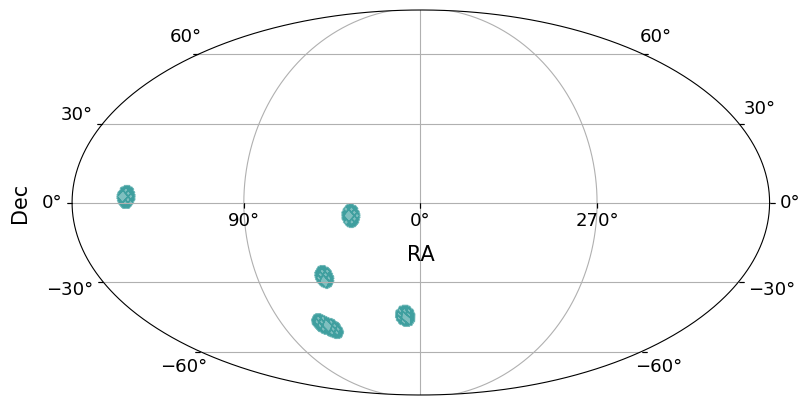

In [4]:
fields = {
    "ELAISS1": (9.45, -44.02),  # ELAIS-S1
    "XMM_LSS": (35.57, -4.82),  # XMM Large Scale Structure
    "ECDFS": (52.98, -28.12),  # Extended Chandra Deep Field South
    "COSMOS": (150.11, 2.23),  # COSMOS
    "EDFS_a": (58.9, -49.32),  # Euclid Deep Field South a
    "EDFS_b": (63.6, -47.60),  # Euclid Deep Field South b
}

cone_mocs = [
    # Using a 4 degree cone around each center.
    region_to_moc.cone_to_moc(ra=ra, dec=dec, radius_arcsec=4 * 3600, max_depth=10)
    for ra, dec in fields.values()
]
cone_moc = reduce(lambda a, b: a.union(b), cone_mocs)
plot_moc(cone_moc)

Let's select the flag columns for filtering:

In [5]:
flag_cols = [f"{band}_pixelFlags_bad" for band in "ugr"]
flag_cols

['u_pixelFlags_bad', 'g_pixelFlags_bad', 'r_pixelFlags_bad']

As well as the extendedness and magnitude information:

In [6]:
columns = ["objectId", "refExtendedness", "refSizeExtendedness"]
columns += [f"{band}_psfMag" for band in "ugr"]
columns += [f"{band}_psfMagErr" for band in "ugr"]
columns += flag_cols
columns

['objectId',
 'refExtendedness',
 'refSizeExtendedness',
 'u_psfMag',
 'g_psfMag',
 'r_psfMag',
 'u_psfMagErr',
 'g_psfMagErr',
 'r_psfMagErr',
 'u_pixelFlags_bad',
 'g_pixelFlags_bad',
 'r_pixelFlags_bad']

In [7]:
filters = [("refExtendedness", ">", 0.7), ("refSizeExtendedness", ">", 0.7)]
filters += [(f"{band}_psfMagErr", "<", 0.05) for band in "ugr"]
filters

[('refExtendedness', '>', 0.7),
 ('refSizeExtendedness', '>', 0.7),
 ('u_psfMagErr', '<', 0.05),
 ('g_psfMagErr', '<', 0.05),
 ('r_psfMagErr', '<', 0.05)]

We can now open the DP2 collection. We will filter for galaxies and select the objects per-band magnitude information.

In [8]:
dp2_galaxies = lsdb.open_catalog(
    "/rubin/lsdb_data/object_collection",
    # Select extendendness and per-band magnitude columns
    columns=columns,
    # Select the Deep Drilling Fields
    search_filter=MOCSearch(cone_moc),
    # Filter by large extendedness to avoid point sources and artifacts
    filters=filters,
)
dp2_galaxies

,objectId,refExtendedness,refSizeExtendedness,u_psfMag,g_psfMag,r_psfMag,u_psfMagErr,g_psfMagErr,r_psfMagErr,u_pixelFlags_bad,g_pixelFlags_bad,r_pixelFlags_bad,coord_ra,coord_dec
npartitions=681,,,,,,,,,,,,,,
"Order: 5, Pixel: 6803",int64[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],bool[pyarrow],bool[pyarrow],bool[pyarrow],double[pyarrow],double[pyarrow]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
"Order: 6, Pixel: 36132",...,...,...,...,...,...,...,...,...,...,...,...,...,...
"Order: 6, Pixel: 36136",...,...,...,...,...,...,...,...,...,...,...,...,...,...


Let's remove any of the galaxies with at least one of the selected flags set:

In [9]:
dp2_galaxies = dp2_galaxies.query("not (" + " or ".join(c for c in flag_cols) + ")")
dp2_galaxies

,objectId,refExtendedness,refSizeExtendedness,u_psfMag,g_psfMag,r_psfMag,u_psfMagErr,g_psfMagErr,r_psfMagErr,u_pixelFlags_bad,g_pixelFlags_bad,r_pixelFlags_bad,coord_ra,coord_dec
npartitions=681,,,,,,,,,,,,,,
"Order: 5, Pixel: 6803",int64[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],bool[pyarrow],bool[pyarrow],bool[pyarrow],double[pyarrow],double[pyarrow]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
"Order: 6, Pixel: 36132",...,...,...,...,...,...,...,...,...,...,...,...,...,...
"Order: 6, Pixel: 36136",...,...,...,...,...,...,...,...,...,...,...,...,...,...


## Crossmatch alerts to galaxies

We then crossmatch the alerts to the DP2 data to find their galaxy hosts:

In [10]:
matches = alerts.crossmatch(
    dp2_galaxies, n_neighbors=3, radius_arcsec=5, min_radius_arcsec=0.02, suffix_method="overlapping_columns"
)
matches

,diaSourceId,ra,dec,objectId,refExtendedness,refSizeExtendedness,u_psfMag,g_psfMag,r_psfMag,u_psfMagErr,g_psfMagErr,r_psfMagErr,u_pixelFlags_bad,g_pixelFlags_bad,r_pixelFlags_bad,coord_ra,coord_dec,_dist_arcsec
npartitions=560,,,,,,,,,,,,,,,,,,
"Order: 7, Pixel: 108955",int64[pyarrow],double[pyarrow],double[pyarrow],int64[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],bool[pyarrow],bool[pyarrow],bool[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
"Order: 6, Pixel: 36129",...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
"Order: 6, Pixel: 36130",...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...


## Plot a color-color diagram

The last step is to calculate the per-band color information for each object in the resulting partitions:

In [11]:
def color_diff(df):
    return {"u-g": df["u_psfMag"] - df["g_psfMag"], "g-r": df["g_psfMag"] - df["r_psfMag"]}


result = matches.map_partitions(color_diff, meta={"u-g": float, "g-r": float})
result

,u-g,g-r
npartitions=560,,
"Order: 7, Pixel: 108955",float64,float64
...,...,...
"Order: 6, Pixel: 36129",...,...
"Order: 6, Pixel: 36130",...,...


Let's setup a Dask Client to more effectively use the hardware available on this RSP machine. Here we assume a large 32GiB RAM instance:

In [12]:
with Client(n_workers=4, memory_limit="8GiB") as client:
    print(f"Dask dashboard: {client.dashboard_link}")
    df = result.compute()

Dask dashboard: http://127.0.0.1:8787/status


Computing Catalog:   0%|          | 0/560 [00:00<?, ?it/s]

Check on progress in the Dask dashboard at: `https://<username>.nb.data-int.lsst.cloud/nb/user/<username>/proxy/8787`. Replace the placeholder with your actual RSP username.

Finally, let's plot the resulting color-color diagram:

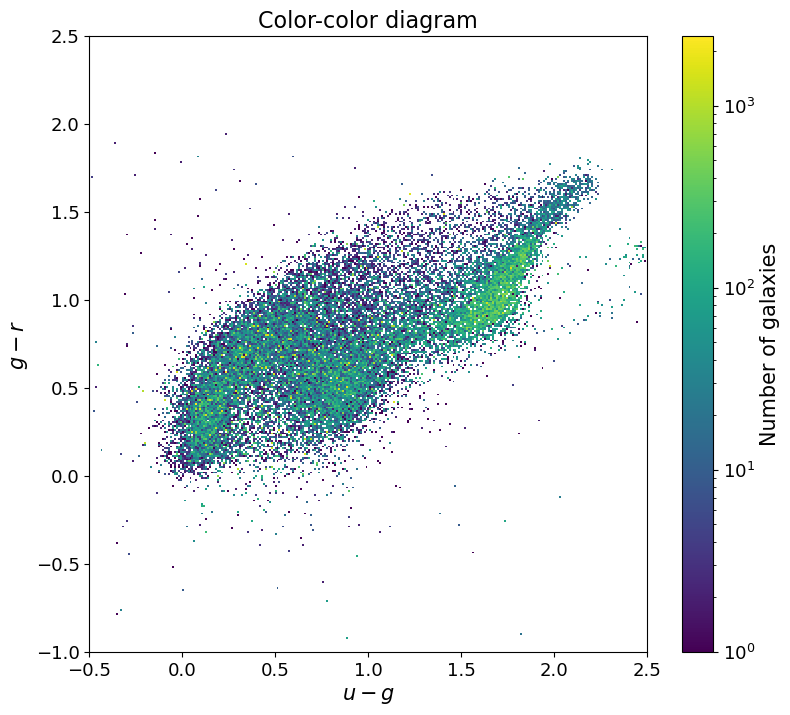

In [13]:
fig, ax = plt.subplots(figsize=(9, 8))
h = ax.hist2d(df["u-g"], df["g-r"], bins=500, cmin=1, norm=LogNorm())
ax.set_xlabel("$u - g$")
ax.set_ylabel("$g - r$")
ax.set_xlim(-0.5, 2.5)
ax.set_ylim(-1, 2.5)
fig.colorbar(h[3], ax=ax, label="Number of galaxies")
ax.set_title("Color-color diagram")
plt.show()

## About

**Authors:** Sandro Campos, Konstantin Malanchev, Neven Caplar

**Last updated/verified on:** Jul 22, 2026

If you use `lsdb` for published research, please cite following [instructions](https://docs.lsdb.io/en/stable/citation.html).